# **Linear Regression**

## Basic Processes in Supervised Learning

### 1. Dataset Selection and Data pre-processing
### 2. Model design/Selection and model building
### 3. Training Model
### 4. Testing and Inferring

## What is training, testing, valiadation dataset

**Training Set:**   is being used to fid the model or train the model. In other words, the data points included in the training set are used to learn the parameters of the model of interest.  In terms of size,  is typically the biggest  
**Test Set:**  is to evaluate the model. The test set is used only once when the final model is evaluated after training. It neither participates in the learning parameter process nor the hyperparameter tuning process.  
**Valiadation Set:** The validation set is used for model selection. More specifically, the validation set does not participate in the determination of learning parameters. The validation set is just for choosing hyperparameters. Validation is sometimes considered a part of the training phase.


**Suppse that students would get Y points in final exam, if they spend X hours in leanring Maching Leanring Course**


**The question is what would be the grade if I study 4 hours**

## Linear Model

**Linear Model: $\hat{y} = x * a + b$**  

In order to evaluate the model error:   
**Training loss(Error): $loss = (\hat{y} - y)^2 = (x * a + b -y)^2$**   --> for one sample   
Calcuate the mean of the loss:  
**Cost Fuction: Mean Square Error(MSE) $cost = $$1\over N$$ \sum_1^n$$(\hat{y}_n - y_n)^2$**  --> for whole dataset

# **Linear Regression from scratch**


import library

In [1]:
import numpy as np
import matplotlib.pyplot as plt


Define our dataset

In [2]:
x_train = [1.0, 2.0, 3.0]
y_train = [5.0, 8.0, 11.0]

Define our forward function/linear model

In [3]:
def forward(x):
  return x * a + b

Define the loss fuction

In [4]:
def loss(x, y):
  y_pred = forward(x)
  return (y_pred - y) ** 2

Create three lists to store the value of weight and the cost value

In [5]:
a_list = []
b_list = []
mse_list = []

Implement the training process by using for loop

In [6]:
for a in np.arange(0.0, 4.0, 0.1):
  for b in np.arange(-2.0, 2.0, 0.1):
    print("a=", a, "b=", b)
    l_sum = 0
    for x_val, y_val in zip(x_train, y_train):
      y_pred_val = a * x_val + b
      loss_val = loss(y_pred_val, y_val)
      l_sum += loss_val
      print('\t', x_val, y_val, y_pred_val, loss_val)

    mse = l_sum / len(x_train)
    print("MSE=", mse)

    a_list.append(a)
    b_list.append(b)
    mse_list.append(mse)

# Now, you can analyze the results in a_list, b_list, and mse_list.


Streaming output truncated to the last 5000 lines.
a= 1.5 b= -2.0
	 1.0 5.0 -0.5 60.0625
	 2.0 8.0 1.0 72.25
	 3.0 11.0 2.5 85.5625
MSE= 72.625
a= 1.5 b= -1.9
	 1.0 5.0 -0.3999999999999999 56.25
	 2.0 8.0 1.1 68.0625
	 3.0 11.0 2.6 81.0
MSE= 68.4375
a= 1.5 b= -1.7999999999999998
	 1.0 5.0 -0.2999999999999998 52.5625
	 2.0 8.0 1.2000000000000002 64.0
	 3.0 11.0 2.7 76.5625
MSE= 64.375
a= 1.5 b= -1.6999999999999997
	 1.0 5.0 -0.19999999999999973 48.999999999999986
	 2.0 8.0 1.3000000000000003 60.062499999999986
	 3.0 11.0 2.8000000000000003 72.25
MSE= 60.43749999999999
a= 1.5 b= -1.5999999999999996
	 1.0 5.0 -0.09999999999999964 45.562499999999986
	 2.0 8.0 1.4000000000000004 56.249999999999986
	 3.0 11.0 2.9000000000000004 68.0625
MSE= 56.62499999999999
a= 1.5 b= -1.4999999999999996
	 1.0 5.0 4.440892098500626e-16 42.249999999999986
	 2.0 8.0 1.5000000000000004 52.56249999999997
	 3.0 11.0 3.0000000000000004 63.99999999999997
MSE= 52.93749999999998
a= 1.5 b= -1.3999999999999995
	 1.0 5.

Draw the graph

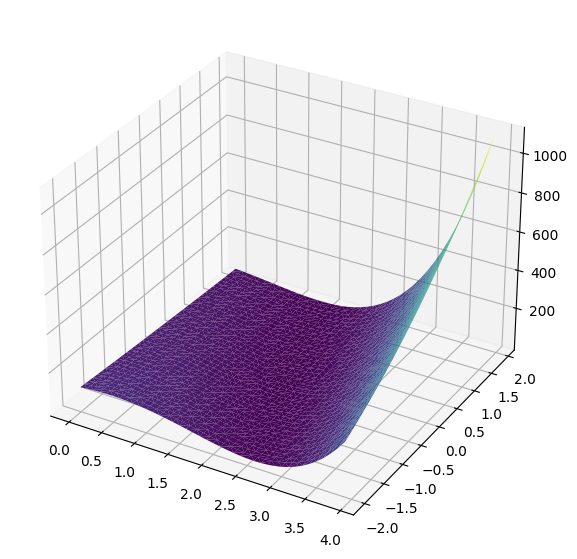

Text(0.5, 0.92, '3D Plot of a, b, and Loss (MSE)')

In [8]:
a_array = np.array(a_list)
b_array = np.array(b_list)
mse_array = np.array(mse_list)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(a_array, b_array, mse_array, cmap='viridis', edgecolor='none')
plt.show()


# Labels and title
ax.set_xlabel('a (slope)')
ax.set_ylabel('b (intercept)')
ax.set_zlabel('MSE (cost)')
ax.set_title('3D Plot of a, b, and Loss (MSE)')

# Show the plot


Exhaustive method

Calculate the cost function corresponding to all weight values, and get the best model by observing the graph.



As the number of learning increases, and multiple weights need to be learned at the same time, the exhaustive method is not a good solution.

In this Optimization Problem, we have Gradient Descent algorithm  
**Mean Square Error(MES) $cost(w) = $$1\over N$$ \sum_1^n$$(\hat{y}_n - y_n)^2$**  
**Optimization Problem: $w^* = arg_wmin$ $cost(w)$**   
**Gradient: $\frac{\partial cost(w)}{\partial w}$**  
**Update: $w = w - \eta \frac{\partial cost(w)}{\partial w}$**  ($\eta$ is the learning rate)  
Substitute the formula of the cost function into the weight update formula  
**Derivative:  
$
\frac{\partial \text{Cost}(a, b)}{\partial a} = \frac{1}{N} \sum_{n=1}^{N} 2x_n \cdot \left( (ax_n + b) - y_n \right)
$

$
\frac{\partial \text{Cost}(a, b)}{\partial b} = \frac{1}{N} \sum_{n=1}^{N} 2 \left( (ax_n + b) - y_n \right)
$

So update formula will be:  
$a = a - \eta \frac{1}{N} \sum_{n=1}^{N} 2x_n \cdot \left( (ax_n + b) - y_n \right)$

$b = b - \eta \frac{1}{N} \sum_{n=1}^{N} 2 \left( (ax_n + b) - y_n \right)$





# **Implement Linear Regression with Gradient Descent from scratch**

Create the same dataset as an example

In [9]:
x_train = [1.0, 2.0, 3.0]
y_train = [5.0, 8.0, 11.0]

Initialize the weight

In [10]:
a = 0
b = 0

Define our forward function/linear model

In [11]:
def forward(x):
  return x * a + b

Define the cost function

In [12]:
def cost(xs, ys):
  cost = 0
  for x, y in zip(xs, ys):
    y_pred = forward(x)
    cost += (y_pred - y) ** 2
  return cost/len(xs)

Define a function to calculate gradient

In [13]:
def gradients(xs, ys):
    grad_a = 0
    grad_b = 0

    for x, y in zip(xs, ys):
        y_pred = a * x + b
        grad_a += 2 * x * (y_pred - y)  # Partial derivative w.r.t 'a'
        grad_b += 2 * (y_pred - y)      # Partial derivative w.r.t 'b'

    grad_a /= len(xs)
    grad_b /= len(xs)
    return grad_a, grad_b

Create a list to store the value of MSE

In [14]:
mse_list = []

Implement the training process

In [15]:

learning_rate = 0.01
for epoch in range(100):  # Number of epochs
    cost_val = cost(x_train, y_train)  # Calculate the current cost (MSE)
    grad_a, grad_b = gradients(x_train, y_train)  # Compute gradients for 'a' and 'b'

    # Update a and b
    a = a - learning_rate * grad_a  # Update 'a' (slope)
    b = b - learning_rate * grad_b  # Update 'b' (intercept)

    # Print progress
    print("Epoch: ", epoch, "a =", a, "b =", b, "loss =", cost_val)
    mse_list.append(cost_val)  # Store MSE for each epoch

Epoch:  0 a = 0.36 b = 0.16 loss = 70.0
Epoch:  1 a = 0.6799999999999999 b = 0.3024 loss = 55.3408
Epoch:  2 a = 0.9644373333333333 b = 0.429152 loss = 43.753440426666664
Epoch:  3 a = 1.2172571022222223 b = 0.5419914666666666 loss = 34.59420667399585
Epoch:  4 a = 1.4419667806814815 b = 0.6424613532444444 loss = 27.354276765430228
Epoch:  5 a = 1.6416847603547655 b = 0.7319334549522962 loss = 21.63145413505048
Epoch:  6 a = 1.819183511190229 b = 0.8116273954390597 loss = 17.107823902604483
Epoch:  7 a = 1.9769279543282452 b = 0.8826275070826693 loss = 13.532091353675938
Epoch:  8 a = 2.1171095783076357 b = 0.9458978387678861 loss = 10.70562145265003
Epoch:  9 a = 2.241676770781541 b = 1.002295498860223 loss = 8.471403824204327
Epoch:  10 a = 2.352361785554188 b = 1.052582518051757 loss = 6.7053301612391225
Epoch:  11 a = 2.4507047181803934 b = 1.0974363962685543 loss = 5.309299482258591
Epoch:  12 a = 2.538074821966148 b = 1.1374594796159674 loss = 4.205768206004477
Epoch:  13 a = 2.6

Draw the plot

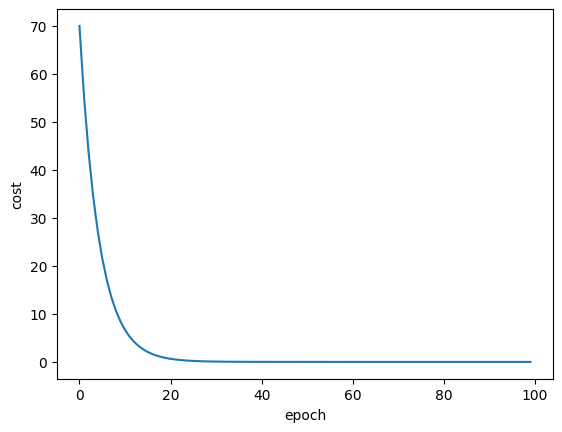

In [16]:
plt.plot(range(100), mse_list)
plt.xlabel("epoch")
plt.ylabel("cost")
plt.show()

Check the weight we learned so far

In [17]:
a, b

(3.197079897743694, 1.5519220323441005)

So when $a \approx 3.197$, $b \approx 1.552$ we get the best model: $\hat{y} = 3.197x + 1.552$

# **Linear Regression Scikit-Learn Example**

## Check the linear relationship betwen `year` and mean `priceperlb` per year.

import libraries

In [18]:
from sklearn import linear_model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


Upload the dataset and show the head 5 lines of the dataset

In [ ]:
dataset = pd.read_csv("/content/honeyproduction.csv")
dataset.head()

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998


Chech the info of the dataset

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        626 non-null    object 
 1   numcol       626 non-null    float64
 2   yieldpercol  626 non-null    int64  
 3   totalprod    626 non-null    float64
 4   stocks       626 non-null    float64
 5   priceperlb   626 non-null    float64
 6   prodvalue    626 non-null    float64
 7   year         626 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 39.2+ KB


Calculate the average price per year, and make it a new table

In [ ]:
production_pre_year = dataset[["year", "priceperlb"]].groupby('year').mean().reset_index()
production_pre_year

,year,priceperlb
0,1998,0.832558
1,1999,0.804186
2,2000,0.791395
3,2001,0.911818
4,2002,1.371364
5,2003,1.494773
6,2004,1.284634
7,2005,1.195122
8,2006,1.303659
9,2007,1.438293


Select the columns **Year** as feature/X/Input

In [ ]:
X = production_pre_year['year']
X.shape
print(type(X))

<class 'pandas.core.series.Series'>


Select the columns **priceperlb** as target/label/output/Y

In [ ]:
Y = production_pre_year['priceperlb']
Y

0     0.832558
1     0.804186
2     0.791395
3     0.911818
4     1.371364
5     1.494773
6     1.284634
7     1.195122
8     1.303659
9     1.438293
10    1.625610
11    1.812000
12    1.929000
13    2.167250
14    2.367000
Name: priceperlb, dtype: float64

Reshape the X, so that we can pass the X parameter to the scikit-learn Linear Regression Model


In [ ]:
X = X.values.reshape(-1, 1)
X.shape

(15, 1)

Plot all observations of X and Y in a scatterplot

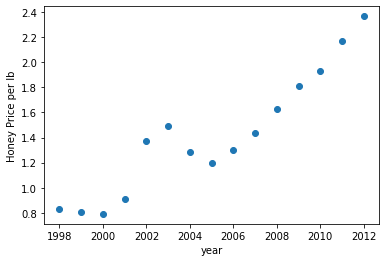

In [ ]:
plt.scatter(X, Y)
plt.xlabel('year')
plt.ylabel('Honey Price per lb')
plt.show()

Instantiate a linear regression model

In [ ]:
model = linear_model.LinearRegression()

Train the model

In [ ]:
model.fit(X, Y)

LinearRegression()

Print out the trained weights

In [ ]:
print(model.coef_)
print(model.intercept_)

[0.10313225]
-205.35825003011024


Using the trained model, make predictions on our training data

In [ ]:
y_pred = model.predict(X)
print(Y)
print(y_pred)

0     0.832558
1     0.804186
2     0.791395
3     0.911818
4     1.371364
5     1.494773
6     1.284634
7     1.195122
8     1.303659
9     1.438293
10    1.625610
11    1.812000
12    1.929000
13    2.167250
14    2.367000
Name: priceperlb, dtype: float64
[0.699985   0.80311724 0.90624949 1.00938174 1.11251399 1.21564624
 1.31877849 1.42191074 1.52504299 1.62817524 1.73130749 1.83443974
 1.93757199 2.04070424 2.14383649]


Plot both predicted and true values on the same graph

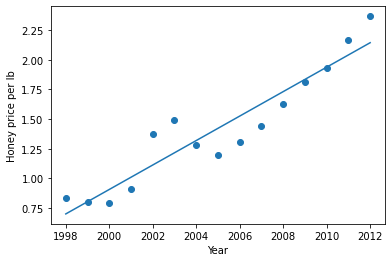

In [ ]:
plt.scatter(X, Y)
plt.plot(X, y_pred)
plt.xlabel('Year')
plt.ylabel('Honey price per lb')
plt.show()

What was our hypothesis/line?

In [ ]:
print(f"y= {round(model.coef_[0], 2)} * x {round(model.intercept_, 2)}")

y= 0.1 * x -205.36


Make new predict by using our trained model

In [ ]:
x_new = [[2022]]
y_pred_new = model.predict(x_new)
print(y_pred_new)

[3.17515899]


https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html